# Hillstrom Email Experiment: EDA and Identification

This notebook prepares the Hillstrom randomized email experiment for uplift modeling. It focuses on the binary comparison between **Men's Email** and **No Email**, with `conversion` as the primary outcome.

## 1. Setup

Load the analysis libraries and raw campaign data.

In [35]:
import pandas as pd
import numpy as np

In [36]:
fp = '../data/raw/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv'

In [37]:
df = pd.read_csv(fp)

## 1.1 Identification Assumptions

Define $T_i=1$ for Men's Email and $T_i=0$ for No Email. For the conversion outcome:

- $Y_i(1)$: whether customer $i$ would convert if they received the Men's Email
- $Y_i(0)$: whether customer $i$ would convert if they received No Email

$$
\tau_i = Y_i(1) - Y_i(0)
$$

Only one potential outcome is observed per customer. A causal interpretation therefore relies on three conditions:

1. **Unconfoundedness:** Random assignment implies $(Y_i(1),Y_i(0)) \perp T_i$.
2. **Positivity:** Both treatment states must be possible across the relevant covariate space: $0<P(T_i=1\mid X_i=x)<1$.
3. **SUTVA:** Customers do not affect one another's outcomes, and each treatment arm represents a consistent intervention.

The following diagnostics check whether the observed data are consistent with these assumptions.

## 1.2 Dataset and Experimental Design

The dataset contains 64,000 customers randomly assigned to three campaign arms:

| Treatment Arm | Customers | Proportion |
|---|---:|---:|
| Men's Email | 21,307 | 33.29% |
| Women's Email | 21,387 | 33.42% |
| No Email | 21,306 | 33.29% |

Outcomes are website visits (`visit`), purchases (`conversion`), and purchase value (`spend`). Their group means are:

| Treatment Arm | Visit Rate | Conversion Rate | Mean Spend |
|---|---:|---:|---:|
| Men's Email | 18.28% | 1.25% | \$1.42 |
| Women's Email | 15.14% | 0.88% | \$1.08 |
| No Email | 10.62% | 0.57% | \$0.65 |

Both email groups outperform control descriptively, with Men's Email showing the largest raw differences. The uplift analysis uses only Men's Email and No Email to create a binary-treatment problem; the Women's Email arm can be evaluated separately.

Randomization, not the balance diagnostics below, is the basis for unconfoundedness. The diagnostics verify that the realized sample is consistent with the experimental design.

Inspect the dataset schema, treatment-arm sizes, and group-level outcomes.

In [38]:
df.info()
df['segment'].value_counts()
df['segment'].value_counts(normalize=True)
df.groupby('segment')[['visit', 'conversion', 'spend']].mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB


,visit,conversion,spend
segment,,,
Mens E-Mail,0.182757,0.012531,1.422617
No E-Mail,0.106167,0.005726,0.652789
Womens E-Mail,0.151400,0.008837,1.077202


In [39]:
df['segment'].value_counts()

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

In [40]:
df['segment'].value_counts(normalize=True).mul(100)

segment
Womens E-Mail    33.417187
Mens E-Mail      33.292187
No E-Mail        33.290625
Name: proportion, dtype: float64

## 1.3 Covariate Inventory

`segment` identifies treatment assignment. Only pre-treatment variables are eligible for the feature matrix $X$:

| Variable | Description | Type |
|---|---|---|
| `recency` | Time since the customer's most recent purchase | Continuous / numeric |
| `history` | Customer's historical spending | Continuous |
| `history_segment` | Categorized version of historical spending | Categorical |
| `mens` | Indicator of previous men's merchandise purchases | Binary |
| `womens` | Indicator of previous women's merchandise purchases | Binary |
| `zip_code` | Customer's geographic area classification | Categorical |
| `newbie` | Indicator of whether the customer is relatively new | Binary |
| `channel` | Customer's previous purchasing channel | Categorical |

`history_segment` is derived from `history`, so later models may retain only one to reduce redundancy. The post-treatment variables `visit`, `conversion`, and `spend` are outcomes and must not be included in $X$.

Review numeric summaries and category frequencies before modeling.

In [41]:
df[['recency', 'history', 'mens', 'womens', 'newbie']].describe()

,recency,history,mens,womens,newbie
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250
std,3.507592,256.158608,0.497393,0.497526,0.499999
min,1.000000,29.990000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000


In [42]:
for col in ['history_segment', 'zip_code', 'channel']:
    print(df[col].value_counts())
    print()

history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308
Name: count, dtype: int64

zip_code
Surburban    28776
Urban        25661
Rural         9563
Name: count, dtype: int64

channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64



## 1.4 Empirical Balance Check

Create the binary analysis sample, then compare numeric and binary covariates with standardized mean differences and categorical covariates with proportion tables and chi-square tests.

In [43]:
df_bin = df[df['segment'].isin(['Mens E-Mail', 'No E-Mail'])].copy()

df_bin['treatment'] = (df_bin['segment'] == 'Mens E-Mail').astype(int)

In [44]:
continuous_cols = ['recency', 'history']

binary_cols = ['mens', 'womens', 'newbie']

categorical_cols = ['history_segment', 'zip_code', 'channel']

In [45]:
def smd(df, col, treatment_col='treatment'):
    treated = df[df[treatment_col] == 1][col]
    control = df[df[treatment_col] == 0][col]

    mean_t = treated.mean()
    mean_c = control.mean()

    var_t = treated.var()
    var_c = control.var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    return (mean_t - mean_c) / pooled_sd

In [46]:
balance_rows = []

for col in continuous_cols + binary_cols:
    treated_mean = df_bin[df_bin['treatment'] == 1][col].mean()
    control_mean = df_bin[df_bin['treatment'] == 0][col].mean()

    balance_rows.append({
        'covariate': col,
        'treated_mean': treated_mean,
        'control_mean': control_mean,
        'smd': smd(df_bin, col)
    })

balance_table = pd.DataFrame(balance_rows)
balance_table

,covariate,treated_mean,control_mean,smd
0,recency,5.773642,5.749695,0.006832
1,history,242.835931,240.882653,0.007613
2,mens,0.550946,0.553224,-0.004582
3,womens,0.551415,0.547639,0.007589
4,newbie,0.501525,0.501971,-0.000892


In [47]:
for col in categorical_cols:
    print(f'\n{col}')
    print(
        pd.crosstab(
            df_bin[col],
            df_bin['segment'],
            normalize='columns'
        )
    )


history_segment
segment           Mens E-Mail  No E-Mail
history_segment                         
1) $0 - $100         0.362510   0.357270
2) $100 - $200       0.220162   0.226978
3) $200 - $350       0.191956   0.189806
4) $350 - $500       0.098418   0.099690
5) $500 - $750       0.074952   0.077537
6) $750 - $1,000     0.030225   0.029194
7) $1,000 +          0.021777   0.019525

zip_code
segment    Mens E-Mail  No E-Mail
zip_code                         
Rural         0.152204   0.147329
Surburban     0.445910   0.451751
Urban         0.401887   0.400920

channel
segment       Mens E-Mail  No E-Mail
channel                             
Multichannel     0.120946   0.122313
Phone            0.433660   0.437764
Web              0.445394   0.439923


In [48]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    table = pd.crosstab(df_bin[col], df_bin['segment'])
    chi2, p, dof, expected = chi2_contingency(table)

    print(col, 'p-value:', p)

history_segment p-value: 0.2863479805603657
zip_code p-value: 0.2830226326656388
channel p-value: 0.5231947749715986


All standardized mean differences are below 0.01, and the categorical distributions are similar across groups. The observed balance is consistent with random assignment.

## 1.5 Positivity and Overlap

Positivity requires both treatment states to occur throughout the relevant covariate space:

$$
0 < P(T=1\mid X=x) < 1
$$

A logistic regression estimates treatment propensity from the pre-treatment covariates. Scores cluster near 0.50 and range from 0.477 to 0.575; none fall below 0.05 or above 0.95. This indicates strong empirical overlap.

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

X = df_bin[
    ['recency', 'history', 'mens', 'womens', 'newbie',
     'history_segment', 'zip_code', 'channel']
]

y = df_bin['treatment']

numeric_cols = ['recency', 'history', 'mens', 'womens', 'newbie']
categorical_cols = ['history_segment', 'zip_code', 'channel']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

propensity_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

propensity_model.fit(X, y)

df_bin['propensity_score'] = propensity_model.predict_proba(X)[:, 1]

/Users/bilal/Documents/PP/causal-uplift/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bilal/Documents/PP/causal-uplift/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bilal/Documents/PP/causal-uplift/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bilal/Documents/PP/causal-uplift/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/bilal/Documents/PP/causal-uplift/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWar

In [50]:
df_bin.groupby('treatment')['propensity_score'].describe()

,count,mean,std,min,25%,50%,75%,max
treatment,,,,,,,,
0,21306.0,0.499819,0.008741,0.477409,0.493817,0.499689,0.505038,0.575048
1,21307.0,0.500130,0.008923,0.477524,0.494006,0.500051,0.505397,0.572372


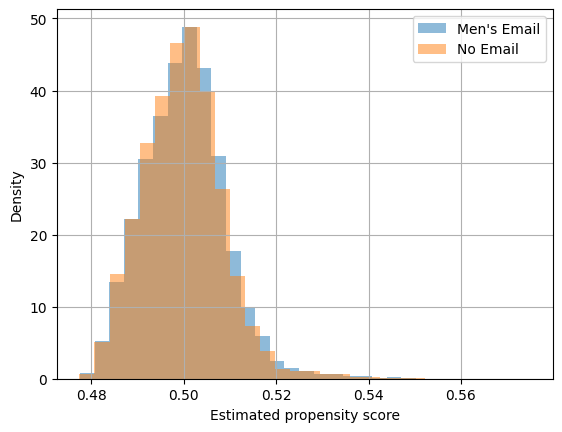

In [51]:
import matplotlib.pyplot as plt

for group, label in [(1, "Men's Email"), (0, "No Email")]:
    df_bin.loc[
        df_bin['treatment'] == group,
        'propensity_score'
    ].hist(
        bins=30,
        alpha=0.5,
        density=True,
        label=label
    )

plt.xlabel('Estimated propensity score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [52]:
df_bin['propensity_score'].describe()

count    42613.000000
mean         0.499974
std          0.008834
min          0.477409
25%          0.493915
50%          0.499870
75%          0.505236
max          0.575048
Name: propensity_score, dtype: float64

In [54]:
df_bin.loc[
    (df_bin['propensity_score'] < 0.05) |
    (df_bin['propensity_score'] > 0.95)
].shape

(0, 14)

## 1.6 SUTVA

SUTVA is plausible here because the email is delivered individually and the treatment arms are well defined. The main residual risks are customer interaction (for example, within households) and unobserved differences in email delivery.

## 1.7 Identification Summary

The Men's Email versus No Email comparison is suitable for causal effect estimation:

- Random assignment supports unconfoundedness.
- Numeric and binary covariates have standardized mean differences below 0.01; categorical distributions are also similar.
- Propensity scores show strong overlap, with no extreme probabilities.
- SUTVA is reasonable for an individually delivered email campaign.

Propensity-score adjustment is not needed to remove confounding in this randomized experiment. The next step is to estimate average and heterogeneous treatment effects with baseline methods and meta-learners.